In [1]:
from DenoiseST import DenoiseST
import os
import torch
import pandas as pd
import numpy as np
import scanpy as sc
from sklearn import metrics
import multiprocessing as mp

adata_path = "/work/data1/GUOMENGKE/CuiYaxuan/SpatialAD/VAEgenerate/H21.33.015_Section_H21.33.015.Cx26.MTG.02.007.1.1_Section_ST_layer56_separation_imputed.h5ad"
adata1 = sc.read_h5ad(adata_path)
adata1

AnnData object with n_obs × n_vars = 27977 × 5056
    obs: 'Donor ID', 'Sex', 'Gender', 'Age at Death', 'Race (choice=White)', 'Race (choice=Black/ African American)', 'Race (choice=Asian)', 'Race (choice=American Indian/ Alaska Native)', 'Race (choice=Native Hawaiian or Pacific Islander)', 'Race (choice=Unknown or unreported)', 'Race (choice=Other)', 'specify other race', 'Hispanic/Latino', 'Highest level of education', 'Years of education', 'PMI', 'Fresh Brain Weight', 'Brain pH', 'Overall AD neuropathological Change', 'Thal', 'Braak', 'CERAD score', 'Overall CAA Score', 'Highest Lewy Body Disease', 'Total Microinfarcts (not observed grossly)', 'Total microinfarcts in screening sections', 'Atherosclerosis', 'Arteriolosclerosis', 'LATE', 'Cognitive Status', 'Last CASI Score', 'Interval from last CASI in months', 'Last MMSE Score', 'Interval from last MMSE in months', 'Last MOCA Score', 'Interval from last MOCA in months', 'APOE4 Status', 'Primary Study Name', 'Secondary Study Name', '

In [2]:
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu') #'cuda:1' if torch.cuda.is_available() else 
#device = torch.device('cpu') 
n_clusters = 7

model = DenoiseST(adata1, device=device,n_top_genes=500)
adata1 = model.train()


/home/guomengke/anaconda3/envs/pipeline/lib/python3.8/site-packages/scanpy/preprocessing/_highly_variable_genes.py:64: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


Begin to train ST data...


  0%|                                           | 1/500 [00:00<03:08,  2.65it/s]

*********************epoch:  0 loss:  tensor(53.1918, device='cuda:1', grad_fn=<AddBackward0>)
0


  1%|▎                                          | 3/500 [00:00<01:33,  5.31it/s]

...

*********************epoch:  495 loss:  tensor(5.7936, device='cuda:1', grad_fn=<AddBackward0>)
0
*********************epoch:  496 loss:  tensor(5.7926, device='cuda:1', grad_fn=<AddBackward0>)
0


100%|████████████████████████████████████████▉| 499/500 [01:16<00:00,  6.51it/s]

*********************epoch:  497 loss:  tensor(5.7916, device='cuda:1', grad_fn=<AddBackward0>)
0
*********************epoch:  498 loss:  tensor(5.7906, device='cuda:1', grad_fn=<AddBackward0>)
0


100%|█████████████████████████████████████████| 500/500 [01:16<00:00,  6.51it/s]


*********************epoch:  499 loss:  tensor(5.7897, device='cuda:1', grad_fn=<AddBackward0>)
0
Optimization finished for ST data!
222222222 [[-0.17530891  0.5034037   0.21472827 ...  2.035126    1.9143388
   1.7028891 ]
 [ 0.35766333  0.8367324   1.7278527  ...  0.5509546   0.8927934
  -0.00995615]
 [-0.3718665  -0.20202625 -0.07844723 ...  0.4566578   0.3019002
   0.31195295]
 ...
 [ 0.45197588  0.68852776  1.33461    ...  2.6523883   3.449572
   1.2287385 ]
 [ 0.1983342   0.16165042  0.22234125 ...  0.287004    0.2637255
   0.46036193]
 [ 0.71716523  1.1855701   1.3252844  ...  0.7231449   0.8980557
   0.9334875 ]]
33333333 tensor([[-0.1753,  0.5034,  0.2147,  ...,  2.0351,  1.9143,  1.7029],
        [ 0.3577,  0.8367,  1.7279,  ...,  0.5510,  0.8928, -0.0100],
        [-0.3719, -0.2020, -0.0784,  ...,  0.4567,  0.3019,  0.3120],
        ...,
        [ 0.4520,  0.6885,  1.3346,  ...,  2.6524,  3.4496,  1.2287],
        [ 0.1983,  0.1617,  0.2223,  ...,  0.2870,  0.2637,  0.4604],


In [3]:
from utils import clustering

radius = 50
tool = 'mclust' # mclust, leiden, and louvain
if tool == 'mclust':
   clustering(adata1, n_clusters, radius=radius, method=tool, refinement=True)
elif tool in ['leiden', 'louvain']:
   clustering(adata_slice, n_clusters, radius=radius, method=tool, start=0.1, end=2.0, increment=0.01, refinement=False)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 5.4.10
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


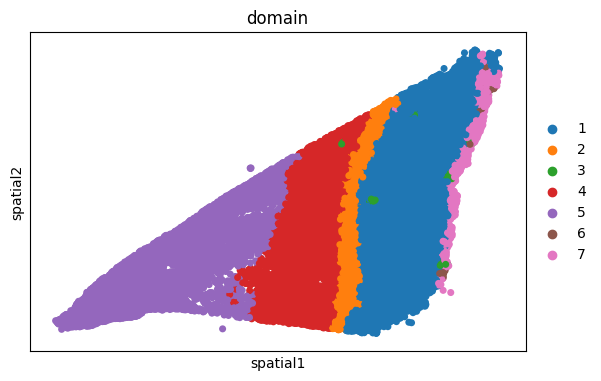

In [4]:


sc.pl.spatial(
    adata1,
    color="domain",
    spot_size=150,
    title="domain"
)

In [5]:
import pandas as pd
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    adjusted_mutual_info_score,
    fowlkes_mallows_score,
    homogeneity_score,
    completeness_score
)

# Ground truth 和 prediction
gt = adata1.obs['Layer annotation']
pred = adata1.obs['domain']

# 去除 Layer annotation 为 NA 的 spot
mask = gt.notna()

gt_valid = gt[mask].astype(str)
pred_valid = pred[mask].astype(str)

# 计算指标
ari = adjusted_rand_score(gt_valid, pred_valid)
nmi = normalized_mutual_info_score(gt_valid, pred_valid)
ami = adjusted_mutual_info_score(gt_valid, pred_valid)
fmi = fowlkes_mallows_score(gt_valid, pred_valid)
homo = homogeneity_score(gt_valid, pred_valid)
como = completeness_score(gt_valid, pred_valid)

# 打印结果
print(f"ARI = {ari:.4f}")
print(f"NMI = {nmi:.4f}")
print(f"AMI = {ami:.4f}")
print(f"FMI = {fmi:.4f}")
print(f"HOMO = {homo:.4f}")
print(f"COMO = {como:.4f}")

ARI = 0.7684
NMI = 0.7354
AMI = 0.7351
FMI = 0.8489
HOMO = 0.6894
COMO = 0.7880
